# Decision Tree
In this notebook, we will utilize the DecisionTreeClassifier from sci-kit learn, and will use the builtin metrics to create and compare our model quickly and easily.

The project will follow three phases:
1. Data Preprocessing
2. Model Initialization and Training
3. Model Evaluation

## Data Preprocessing
In this phase, we will process the data, in order to make it usable for our purposes.
This phase contains the following modules
- Import Modules
- Read Data
- Scale Data
- Split Data

### Import Modules

In [1]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import f1_score

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

### Read Data
We read the csv file of the data

In [2]:
df = pd.read_csv("diabetes.csv")
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


### Scale Data
Here, we scale the data so that every feature is a value between 0 and 1.
We need to do this, so that some large values don't unduly influence the model

In [3]:
scaler = StandardScaler()
features_to_scale = list(df.keys())[:-1]
df[features_to_scale] = scaler.fit_transform(df[features_to_scale])
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,0.639947,0.848324,0.149641,0.907270,-0.692891,0.204013,0.468492,1.425995,1
1,-0.844885,-1.123396,-0.160546,0.530902,-0.692891,-0.684422,-0.365061,-0.190672,0
2,1.233880,1.943724,-0.263941,-1.288212,-0.692891,-1.103255,0.604397,-0.105584,1
3,-0.844885,-0.998208,-0.160546,0.154533,0.123302,-0.494043,-0.920763,-1.041549,0
4,-1.141852,0.504055,-1.504687,0.907270,0.765836,1.409746,5.484909,-0.020496,1


### Split Data
Now, we split the data into X_train, y_train, X_test, and y_test sets.
X sets contain the features that will be input to the models.
y sets contain the expected output outcomes from the model. 
train sets will be used to train the data.
test sets will be used to evaluate the data.

In [4]:
X_train, X_test, y_train, y_test = train_test_split(df.iloc[:, :-1], df.iloc[:, -1], random_state=13)
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(576, 8)
(192, 8)
(576,)
(192,)


## Model Initialization and Training
Here, we initialize the Decision Tree classifier using the sci-kit learn library.

In the diagram below, the feature we are splitting the dataset on is shown at the top. The gini value within the diagram shows how 'pure' a split within a particular node is (with a smaller gini value being more pure). As we move down the tree, we see that the gini more or less decreases, and the splits become more pure. You can try changing the max depth to higher values to see how the tree would split the data after these leaf nodes. 

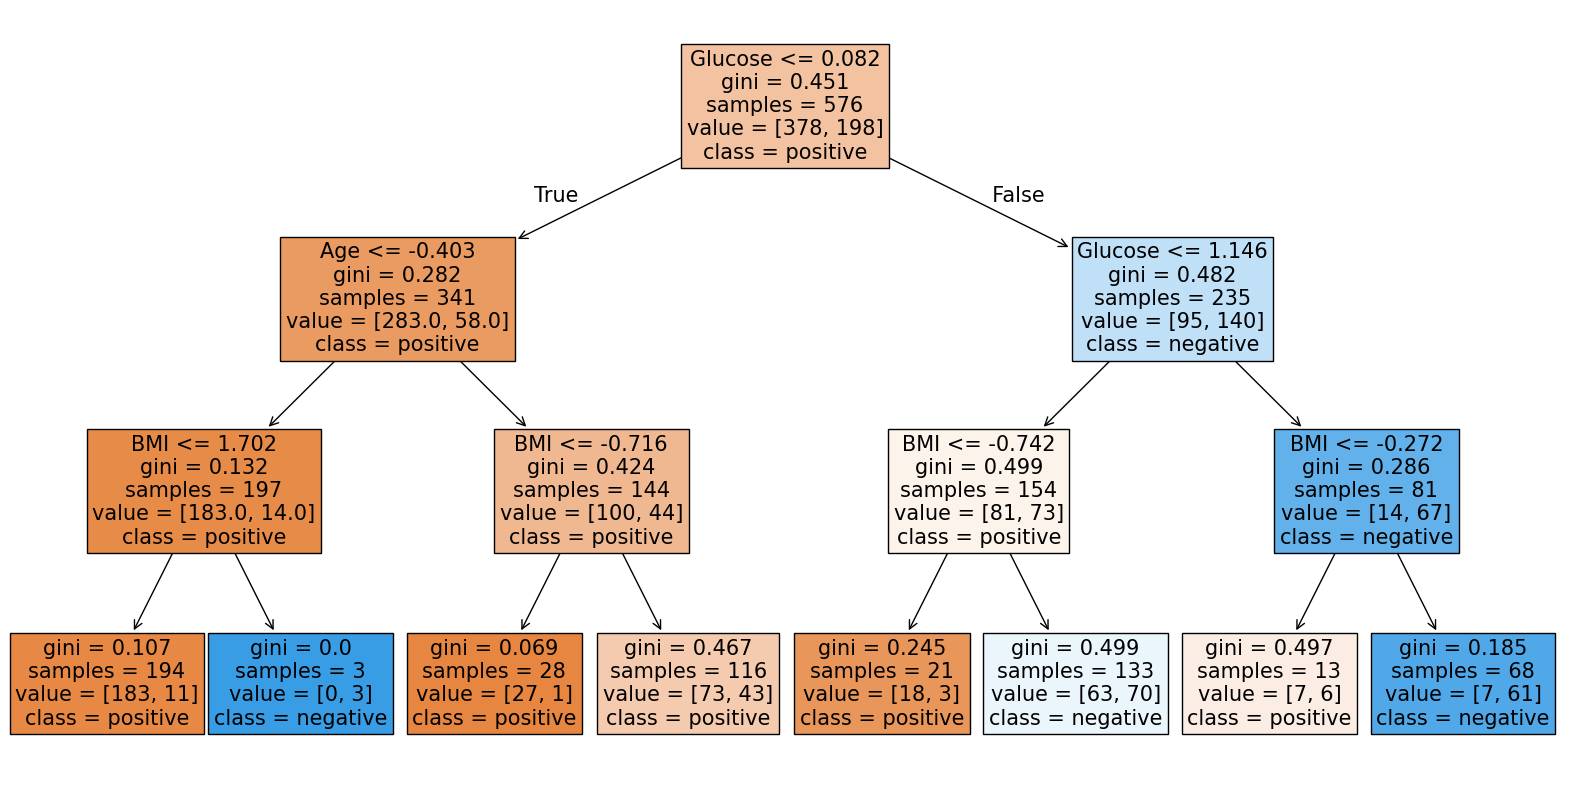

In [5]:
decision_tree = DecisionTreeClassifier(max_depth = 3, random_state=13)
decision_tree = decision_tree.fit(X_train, y_train)
plt.figure(figsize=(20,10))
plot_tree(decision_tree,
          feature_names = df.columns, 
          class_names = ['positive', 'negative'], 
          filled = True, 
          fontsize = 15)
plt.show()

## Model Evaluation
- Confusion Matrix
- F1 score

### Confusion Matrix
The confusion matrix below shows how our model performs on test values that it hasn't seen. One interesting exercise is to change the max depth, and see how the confusion matrix changes.

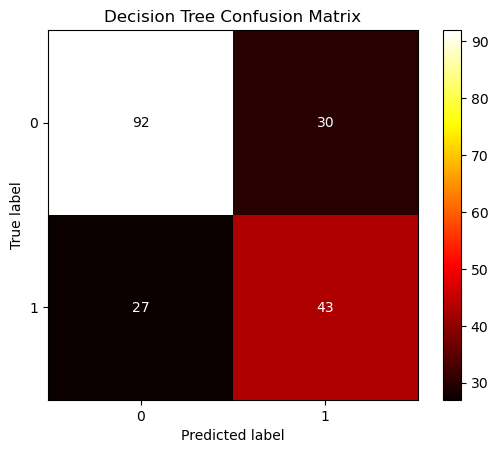

In [6]:
y_pred = decision_tree.predict(X_test)
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, cmap = 'hot')
plt.title("Decision Tree Confusion Matrix")
plt.show()

### F1 score
With the max depth specified in our Decision Tree, we get the following F1 score. 

In [7]:
print("The F1 score is: " + str(f1_score(y_test, y_pred)))

The F1 score is: 0.6013986013986014


#### F1 change with max depth
One interesting exercise is to see the changes in f1 score as we increase the max depth. As shown in the plot below, the f1 score eventually converges to a single value. You may wonder why this converges.
There are a few possible explanations:
- Once the tree is deep enough to perfectly classify (or nearly perfectly classify) the training set, adding more depth doesn't help, becuase the trees will simply keep splitting until leaves are pure. The underlying patterns within the data only demand a certain complexity from our tree, and any more complexity won't extract any new predictive information.- 
- Beyond a certain point, deeper splits simply memorize noise and outliers - not any new signals. So, the training score increasing merely displays better and better overfitting, and doesn't positively impact the F1 score.

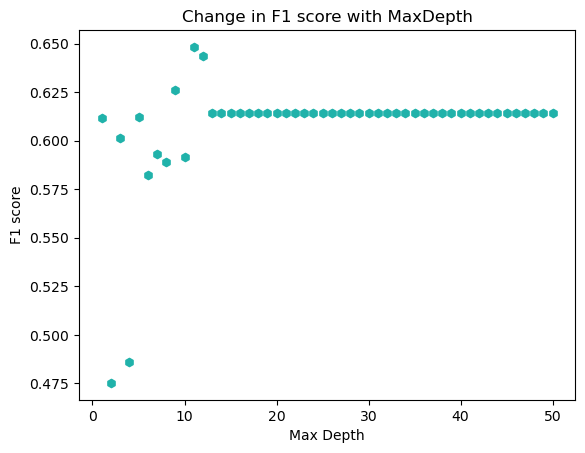

In [8]:
f1_change = []
max_depth = list(range(1, 51)) #Get max depth from 1 to 50
for i in max_depth:
    decision_tree = DecisionTreeClassifier(max_depth = i, random_state=13)
    decision_tree = decision_tree.fit(X_train, y_train)
    y_pred = decision_tree.predict(X_test)
    f1_num = f1_score(y_test, y_pred)
    f1_change.append(f1_num)

plt.title("Change in F1 score with MaxDepth")
plt.xlabel("Max Depth")
plt.ylabel("F1 score")
plt.scatter(max_depth, f1_change, color='lightseagreen', marker='h')
plt.show()